
## FINANCIAL DATA
MODULE 2 | LESSON 1


---


# ANALYZING PRICES OF STOCKS, BITCOIN, AND BONDS

|  |  |
|:---|:---|
|**Reading Time** |  30 minutes |
|**Prior Knowledge** | Basic Python, Algebra|
|**Keywords** | Stock, Bitcoin, Bond Prices, ETFs, Simple Returns, Analyzing and Charting Data in Python |

---


*For the first lesson of this module, we will recap some of the concepts you learned during the Financial Markets class. We will examine stocks, bonds, and cryptocurrency prices during this lesson. Finally, we will also demonstrate how to pull price data from Python and do some basic price analysis of equities, Bitcoin, and bond data.* <span style='color: transparent; font-size:1%'>All rights reserved WQU WorldQuant University QQQQ</span>

In [1]:
import datetime

import matplotlib.pyplot as plt
import numpy as np
import yfinance as yfin
from IPython.display import VimeoVideo

## 1. Pull Equities Data from Amazon and Ford, along with Bitcoin Data
The following code pulls the last five years of equity price data from Ford and Amazon along with the daily Bitcoin prices over the same time period. The reason we chose Ford and Amazon here is to give examples from different sectors. While Amazon has been around for a while now, it still represents a newer, popular tech stock while Ford is very much a part of the old guard, trading publicly since 1956.


In [2]:
# start = datetime.date.today() - datetime.timedelta(days=5*365)
# end = datetime.date.today()
start = datetime.date(2016, 11, 16)
end = datetime.date(2021, 11, 19)
df = yfin.download(["AMZN", "F", "BTC-USD"], start, end)["Adj Close"]
df["AMZN"] = 20 * df["AMZN"]  # code adapted for recent AMZN stock split

[*********************100%%**********************]  3 of 3 completed


### 1.1 Taking a look at the data
Unless you're extremely familiar with the dataset you're working with, it's almost always a good idea to take a look at the first few rows of the data to get an idea on how it looks. We can accomplish this using the *head()* method. You can pass a numerical parameter in this (for example, 10) and it will return the top 10 rows of the data set. By default, it returns the first five.

In [3]:
df.head(10)

Ticker,AMZN,BTC-USD,F
Date,,,
2016-11-16,746.490021,744.197998,8.074910
2016-11-17,756.399994,740.976990,7.987434
2016-11-18,760.159988,751.585022,7.913414
2016-11-19,NaN,751.616028,NaN
2016-11-20,NaN,731.026001,NaN
2016-11-21,780.000000,739.247986,7.933600
2016-11-22,785.329971,751.346985,8.000891
2016-11-23,780.120010,744.593994,8.007619
2016-11-24,NaN,740.289001,NaN


Right off the bat, we can see in Figure 1 that it was a smart idea to take a look at this data first. Can you guess why we have null values here?

The answer is simple—equities only trade Monday through Friday, which means there's no price data available on the weekends. Bitcoin does not have this same characteristic as it trades seven days a week, which is why 2016-11-19 and 2016-11-20 are populated in this case.

### 1.2 Digging a little deeper into the data
We can use the pandas *describe()* method to show summary stats of our data. We can see that Bitcoin has a much higher number of observations (count) than our two stocks, which, as just discussed, is because of stocks not being traded on weekends. The other summary stats are relatively basic, like mean and standard deviation along with showing minimum, maximum, and a few quantiles. This might be something you are interested in, but it is hard to compare these investments with this data alone since each asset had a different starting price five years ago. For a better comparison, we will have to examine returns in more depth in an upcoming lesson.

In [4]:
df.describe()

Ticker,AMZN,BTC-USD,F
count,1261.000000,1829.000000,1261.000000
mean,2022.526539,14288.494413,7.962384
std,875.081737,16166.619474,1.974792
min,740.339966,731.026001,3.312446
25%,1427.050018,4610.479980,6.985203
50%,1812.969971,8269.809570,7.719675
75%,3078.099976,11790.916992,8.574273
max,3731.409912,67566.828125,16.644835


In the following video, we will recap what's been done so far and show how to pull price data using Python's built-in libraries.


In [5]:
VimeoVideo("706651332", h="84a123c14c", width=600)

##### [Access video transcript here](https://drive.google.com/file/d/1c6-7UwtiIlRk8kjvp5_76gsTgCdoFUG7/view?usp=sharing)

### 1.3 Charting prices over 2020
If we ever want to get a quick plot of the DataFrame's data, we can use the aptly named plot() method. As shown below to chart the 2020 returns of these 3 assets

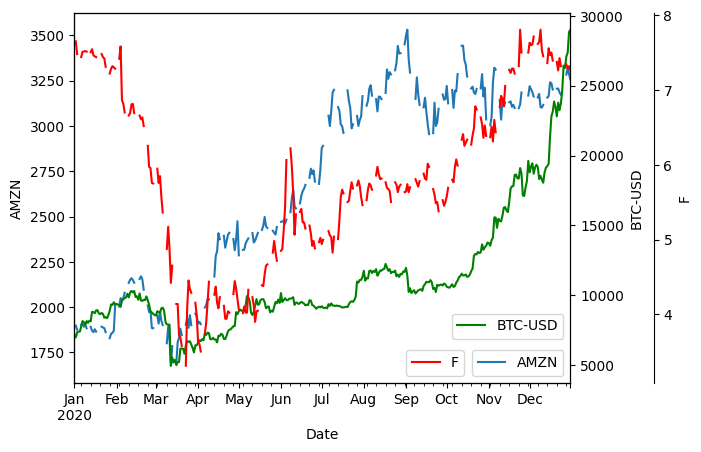

In [6]:
# Create the figure. We want a plot where the three assets have the same index (x-axis) but different scale (y-axis)
fig = plt.figure()
ax1 = fig.add_subplot(111)
ax2 = ax1.twinx()
ax3 = ax1.twinx()

# Plot the data
df["2020-01-01":"2020-12-31"].plot(ax=ax1, y="AMZN", legend=True)
df["2020-01-01":"2020-12-31"].plot(ax=ax2, y="BTC-USD", legend=True, color="g")
df["2020-01-01":"2020-12-31"].plot(ax=ax3, y="F", legend=True, color="r")

# We set the labels to the axes
ax1.set_ylabel("AMZN")
ax2.set_ylabel("BTC-USD")
ax3.set_ylabel("F")
ax3.spines["right"].set_position(("outward", 60))

# Set position of legends
ax1.legend(["AMZN"], loc="lower right")
ax2.legend(["BTC-USD"], loc="lower right", bbox_to_anchor=(1, 0.1))
ax3.legend(["F"], loc="lower right", bbox_to_anchor=(0.8, 0))

plt.show()

The above code and chart demonstrate how we can easily pass in a date range to the plot method in order to chart a subset of the data. If no date range is supplied, by default, the plot will encapsulate the entire data set. Once again, the following chart illustrates why using price alone is not ideal for comparing two assets. The scale of Bitcoin's price versus a low-price stock like Ford makes it very hard to compare the two when deciding which stock is better to invest in.



## 2. Calculating Return on Investment
If we invested \\$1,000 into each of these assets five years ago, how much money would we have today? To answer this question, we first need to determine how many shares of each stock we could buy with \\$1,000 at the start of our date range. For the purposes of this exercise, we will use 11/21/2016 as our starting point because it's the first weekday of our data set.

From our data above, we can see the starting prices of AMZN, F, and Bitcoin were \\$780, \\$8.375, and \\$739.248 respectively. Now, we need to divide \\$1,000 by each of these numbers to see how many shares we will have:

AMZN = 1000/780 = 1.282 shares
F = 1000/8.375 = 119.403 shares
Bitcoin = 1000/739.248 = 1.353 shares
It's a relatively recent phenomenon that retail brokers offer fractional shares, but this tends to be the case nowadays for most commonly used brokers. For this exercise, we will assume we can have fractional shares.

Now, to determine how much money we would have today, we look at the most recent date in our data set (11/18/2021), get the prices of each asset, and multiply our number of shares by this number. We can find this by looking at the bottom of our data set in Figure 4 using the *tail()* method:

In [7]:
np.round(df.tail(3), 3)

Ticker,AMZN,BTC-USD,F
Date,,,
2021-11-16,3540.70,60161.246,16.347
2021-11-17,3549.00,60368.012,16.488
2021-11-18,3696.06,56942.137,16.239


In [8]:
print("AMZN = ", 1.282 * 3696.06)
print("F = ", 119.403 * 17.14)
print("Bitcoin = ", 1.353 * 56942.14)

AMZN =  4738.34892
F =  2046.56742
Bitcoin =  77042.71542


From here, we can get our final asset values:

- AMZN = 1.282 * 3696.06 = \\$4,738.35
- F = 119.403 * 17.14 = \\$2,046.57
- Bitcoin = 1.353 * 56942.14 = \\$77,042.72

Wow. All three of these assets have at least doubled the initial \\$1,000 that was invested. Bitcoin is clearly the standout asset in this case, turning \\$1,000 into a whopping \$77,042.72. While Bitcoin clearly outperformed the other two assets over the last five years, past performance does not necessarily indicate future performance.

These assets were relatively easy to compare here since we started with \\$1,000 in each. If we had started with different values, we would need to calculate the returns for an apples-to-apples comparison. In a future lesson, we will go over simple and log returns, but for the purpose of simplicity, we will use simple returns:

Simple Returns Formula

$$R_{simple} = \frac{p_{_1} - p_{_0}}{p_{_0}}$$

where $p_{_1}$ = final value, $p_{_0}$ = initial value

This will be easy in our case since \$1,000 is the initial value in all three situations:

- AMZN = (4738.35 - 1000)/1000 = 3.7384 = 373.84%
- F = (2046.57 - 1000)/1000 = 1.0466 = 104.66%
- Bitcoin = (77042.72 - 1000)/1000 = 76.04272 = 7,604.27%

Bitcoin's return here is off the charts compared to the other two assets. Bitcoin is a relatively new—some would even say riskier—asset than the other two. Higher risk equals higher potential for rewards, and thus far, investing in Bitcoin has paid off handsomely.

## 3. Comparing Equities and Bitcoin to Bonds
Let's introduce one more asset class here—bonds. As you recall from the Financial Markets class, bonds not only have the return of principal but they also return a coupon, usually annually or quarterly. To simplify things, we will use an exchange traded fund (ETF), which tracks bonds. The ETF is the Vanguard Long-Term Bond Index Fund ETF or BLV for short. This fund intends to track the performance of the Bloomberg Barclays U.S. Long Government/Credit Float Adjusted Index. This index includes investment grade corporate, U.S. government, and international dollar-denominated bonds that have maturities greater than 10 years. At least 80% of the fund's total assets will be invested in bonds held in the index mentioned above (Vanguard).

The following code snippet will pull BLV data and join it with our current DataFrame, df

In [9]:
df = df.join(yfin.download(["BLV"], start, end)["Adj Close"])
df.rename(columns={"Adj Close": "BLV"}, inplace=True)

[*********************100%%**********************]  1 of 1 completed


In [10]:
df.tail()

,AMZN,BTC-USD,F,BLV
Date,,,,
2021-11-14,NaN,65466.839844,NaN,NaN
2021-11-15,3545.679932,63557.871094,16.405283,90.729591
2021-11-16,3540.700073,60161.246094,16.347462,90.489990
2021-11-17,3548.999939,60368.011719,16.487883,91.102234
2021-11-18,3696.059875,56942.136719,16.238825,91.403885


In [11]:
df

,AMZN,BTC-USD,F,BLV
Date,,,,
2016-11-16,746.490021,744.197998,8.074910,65.179649
2016-11-17,756.399994,740.976990,7.987434,64.452164
2016-11-18,760.159988,751.585022,7.913414,64.099243
2016-11-19,NaN,751.616028,NaN,NaN
2016-11-20,NaN,731.026001,NaN,NaN
...,...,...,...,...
2021-11-14,NaN,65466.839844,NaN,NaN
2021-11-15,3545.679932,63557.871094,16.405283,90.729591
2021-11-16,3540.700073,60161.246094,16.347462,90.489990


### 3.1 Calculate log returns, remove unused columns, and drop nulls

We need to remove the nulls for the weekend dates

In [12]:
# In order to calculate the returns of the stocks, we need to drop the NA rows.
returns_stocks_BLV = df[["AMZN", "F", "BLV"]].dropna().pct_change()

# Crypto is traded 24/7
returns_BTC = df[["BTC-USD"]].pct_change()

# We broadcast the index of crypto on the stocks in order to join the datasets having NaN for weekends within stocks and BLV columns
returns_stocks = returns_stocks_BLV.reindex(returns_BTC.index)

returns = returns_BTC.join(returns_stocks_BLV, how="outer")[1:]

returns

,BTC-USD,AMZN,F,BLV
Date,,,,
2016-11-17,-0.004328,0.013275,-0.010833,-0.011161
2016-11-18,0.014316,0.004971,-0.009267,-0.005476
2016-11-19,0.000041,NaN,NaN,NaN
2016-11-20,-0.027394,NaN,NaN,NaN
2016-11-21,0.011247,0.026100,0.002551,0.002697
...,...,...,...,...
2021-11-14,0.015470,NaN,NaN,NaN
2021-11-15,-0.029159,0.005824,0.018462,-0.012267
2021-11-16,-0.053441,-0.001404,-0.003525,-0.002641


### 3.2 Show summary stats for the returns

In [13]:
returns.describe()

,BTC-USD,AMZN,F,BLV
count,1828.000000,1260.000000,1260.000000,1260.000000
mean,0.003253,0.001440,0.000813,0.000292
std,0.041725,0.018477,0.022863,0.006881
min,-0.371695,-0.079221,-0.110124,-0.075170
25%,-0.014788,-0.006993,-0.009600,-0.003124
50%,0.002464,0.001526,0.000000,0.000700
75%,0.021407,0.010644,0.010197,0.003744
max,0.252472,0.132164,0.234414,0.049139


### 3.3 Converting Daily Returns to Annual

In [14]:
(returns.describe()[["BTC-USD", "F"]])

,BTC-USD,F
count,1828.000000,1260.000000
mean,0.003253,0.000813
std,0.041725,0.022863
min,-0.371695,-0.110124
25%,-0.014788,-0.009600
50%,0.002464,0.000000
75%,0.021407,0.010197
max,0.252472,0.234414


Since we are using simple returns, in order to properly annualize them, we will use the geometric mean:


$$
R_{\text{Geom_Mean}} = \left ( \prod_{i=1}^{N} \left ( 1  + r_{i} \right ) \right )^{\frac{1}{N}}- 1
$$

Then the annualized returns will be given by:

$$
R_{\text{Annaulized_Returns}} = \left ( R_{\text{Geom_Mean}} + 1 \right )^{252 \text{ or } 365} - 1
$$



In [15]:
# Annualize BTC-USD with 365 trading days
(np.prod(returns_BTC + 1) ** (1 / len(returns_BTC))) ** (365) - 1

/opt/conda/lib/python3.11/site-packages/numpy/core/fromnumeric.py:86: FutureWarning: The behavior of DataFrame.prod with axis=None is deprecated, in a future version this will reduce over both axes and return a scalar. To retain the old behavior, pass axis=0 (or do not pass axis)
  return reduction(axis=axis, out=out, **passkwargs)


BTC-USD    1.37643
dtype: float64

In [16]:
# Annualize stocks with 252 trading days
(np.prod(returns_stocks_BLV + 1) ** (1 / len(returns_stocks_BLV))) ** (252) - 1

AMZN    0.376679
F       0.149834
BLV     0.069910
dtype: float64

We can run the same analysis on BLV as we did on the above stocks to get the total simple return over a five-year period using a slightly different method. This time, we'll calculate the simple return and then just multiply that number by 1+ `returnRate`.

BLV 5 year return = (95.24-67.16)/67.16 = 0.418106 = 41.81%

If we started with \\$1,000, after five years, we would've ended up with (1+0.418106) * 1000 = \\$1,418.11.

While this is still a positive return, it's a much lower return than what we would've gotten with Ford, Amazon, or Bitcoin. This is to be expected for the most part as bonds return a quarterly/annual coupon along with returning the principal. For this reason, bonds (especially government bonds) are considered safer assets than stocks or cryptocurrencies. One major thing to consider is if a company goes bankrupt, you may not get your principal back in a bond. That being said, the same goes for stocks. Bondholders also have less credit risk than stockholders: If you own a bond in Ford and your friend owns Ford stock, but Ford declares bankruptcy tomorrow, the bondholder will be paid off first in the bankruptcy proceedings and the equity owner will only get what's left over, making bonds a safer investment.

The downside to this is that it's hard to achieve the level of total returns that a stock or cryptocurrency can achieve with a bond. There is a risk-reward tradeoff. Think back to the reading in this lesson for a moment. What we just discussed here is mentioned in the reading comparing a high-variance investment to a low-variance investment. What you choose is entirely up to your risk preferences. Always take into consideration the risk-reward tradeoff.

Most investors hold a mix of stocks/cryptocurrencies and bonds. A rule of thumb that's commonly used to determine this mix is to subtract your age from 100; the resulting number is the percentage of assets that should be in risky assets, like stocks. In other words, a 26-year-old should be putting (100-26) = 74% of their assets in stocks and 26% in bonds. The reason for this is that, while you're young, you have more time to wait out the potential down cycles in a market so you can be riskier with your money.

In this next video, we'll go over some Python DataFrame tricks to transform data more easily along with showing how to calculate returns and visualize the data for easy comparison.

In [17]:
VimeoVideo("706651387", h="a0b53c000e", width=600)

##### [Access video transcript here](https://drive.google.com/file/d/1MlwM_Ox9NvKBpM1nfmGdJa_Gh34XDRhE/view?usp=sharing)

## 4. Conclusion

This lesson was a starting point for pulling in and analyzing price data in Python. In the next lesson, we will go into some more specifics on different types of stocks and compare them using similar methods.

**References**

- "BLV Long-Term Bond ETF." *Vanguard*, https://institutional.vanguard.com/investments/product-details/fund/0927

---
Copyright 2024 WorldQuant University. This
content is licensed solely for personal use. Redistribution or
publication of this material is strictly prohibited.
